In [47]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

In [48]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [49]:
# Set seeds
def set_seeds(seed: int=42):
    """Sets random sets for torch operations.

    Args:
        seed (int, optional): Random seed to set. Defaults to 42.
    """
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)

set_seeds()

In [50]:
# 1. Get pretrained weights for ViT-Base
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT

# 2. Setup a ViT model instance with pretrained weights
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

# 3. Freeze the base parameters
for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False

# 4. Change the classifier head
class_names = ['mutu1','mutu2','mutu3','mutu4','mutu5','mutu6']

set_seeds()

# Add dropout layer and weight decay
pretrained_vit.heads = nn.Sequential(
    nn.Dropout(0.1),
    nn.Linear(in_features=768, out_features=len(class_names))
).to(device)

In [51]:
import os

pred_class_path = '/kaggle/input/prediction-arabica-class/pred_class'
pred_list = []

for root, dirs, files in os.walk(pred_class_path):
    for file in files:
        if file.endswith('.jpg'):
            pred_list.append((os.path.join(root, file), class_names.index(root.split('/')[-1])))

pred_list.sort(key=lambda x: x[1])
pred_list = [item[0] for item in pred_list]

In [52]:
# Load the model weights
model_weights = torch.load('/kaggle/input/vit-arabica-weight/weight_vit/vit-imgt-16(7030).pth')

# Create a model instance and load the weights into it
model = pretrained_vit
model.load_state_dict(model_weights)

<All keys matched successfully>

In [53]:
import itertools

actual_labels = [name for name in itertools.chain.from_iterable(itertools.repeat(class_name, 10) for class_name in class_names)]

In [54]:
def predict_image(image_path, model, class_names):
    # Load the image
    image = Image.open(image_path)

    # Define transformations to be applied to the image
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize the image to the expected input size of the model
        transforms.ToTensor(),           # Convert the image to a PyTorch tensor
        transforms.Normalize(            # Normalize the image
            mean=[0.485, 0.456, 0.406],   # Mean and standard deviation values for ImageNet dataset
            std=[0.229, 0.224, 0.225]
        )
    ])

    # Apply the transformations to the image
    input_image = transform(image).unsqueeze(0)  # Add batch dimension

    # Set the device to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Move the input tensor to the device
    input_image = input_image.to(device)

    # Set the model to evaluation mode
    model.eval()

    # Perform inference
    with torch.no_grad():
        outputs = model(input_image)

    # Get the logits from the output object
    logits = outputs

    # Apply softmax to get probabilities
    probabilities = torch.softmax(logits, dim=1)

    # Get the predicted class index
    predicted_class_idx = torch.argmax(probabilities).item()

    # Get the class label corresponding to the predicted index
    predicted_class_label = class_names[predicted_class_idx]

    # Get the probability score for the predicted class
    predicted_probability = probabilities[0, predicted_class_idx].item()
    
    # Get predicted labels
    predicted_labels.append(predicted_class_label)

In [55]:
from PIL import Image
import time  # Import modul time

# Get predicted labels
predicted_labels = []

prediction_times = []  # List to store prediction times
    
# Get prediction images    
image_paths = pred_list

times = []

# Iterate over the images and make predictions
for image_path in image_paths:
    start_time = time.time()  # Start time
    predict_image(image_path, model, class_names)
    end_time = time.time()  # End time        times.append(end_time - start_time)
    times.append(end_time - start_time)
    
#prediction_times.append(np.mean(times))  # Store the average prediction time
times

[0.16756176948547363,
 0.1715238094329834,
 0.17068266868591309,
 0.16579532623291016,
 0.16588306427001953,
 0.16804003715515137,
 0.16589736938476562,
 0.16951847076416016,
 0.16209077835083008,
 0.1663498878479004,
 0.16907882690429688,
 0.16747570037841797,
 0.16316747665405273,
 0.16911005973815918,
 0.16478633880615234,
 0.16418218612670898,
 0.17039990425109863,
 0.17087745666503906,
 0.16097521781921387,
 0.164503812789917,
 0.16700458526611328,
 0.16356492042541504,
 0.17520666122436523,
 0.1682291030883789,
 0.16672468185424805,
 0.16874408721923828,
 0.16467928886413574,
 0.17146635055541992,
 0.16422009468078613,
 0.16956496238708496,
 0.16421866416931152,
 0.16731643676757812,
 0.16177153587341309,
 0.16768670082092285,
 0.16318297386169434,
 0.16817712783813477,
 0.16639924049377441,
 0.16177034378051758,
 0.1663832664489746,
 0.16321897506713867,
 0.16573762893676758,
 0.16380643844604492,
 0.16528987884521484,
 0.1633157730102539,
 0.16143131256103516,
 0.14545774459838

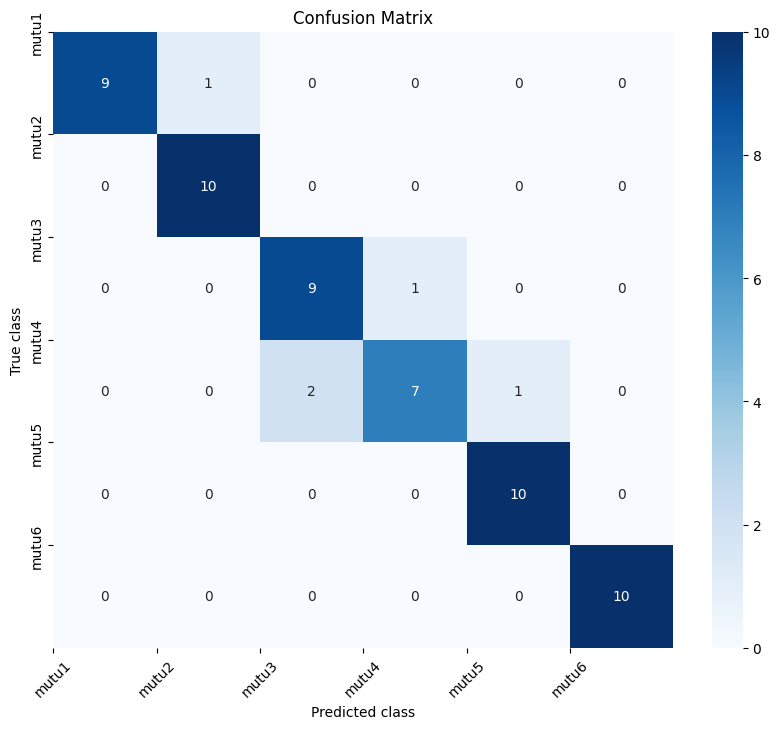

In [56]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def calculate_confusion_matrix(actual_labels, predicted_labels):
    cm = confusion_matrix(actual_labels, predicted_labels)
    return cm

confusion_matrix_data = calculate_confusion_matrix(actual_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_data, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.show()

In [57]:
accuracy = np.trace(confusion_matrix_data) / np.sum(confusion_matrix_data)
precision = np.diag(confusion_matrix_data) / np.sum(confusion_matrix_data, axis=0)
recall = np.diag(confusion_matrix_data) / np.sum(confusion_matrix_data, axis=1)
f1_score = 2 * (precision * recall) / (precision + recall)
prediction_times.append(np.mean(times))  # Store the average prediction time

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)
print(f"Average Prediction Time per Image: {np.mean(times)} seconds")  # Print average prediction time

Accuracy: 0.9166666666666666
Precision: [1.         0.90909091 0.81818182 0.875      0.90909091 1.        ]
Recall: [0.9 1.  0.9 0.7 1.  1. ]
F1 Score: [0.94736842 0.95238095 0.85714286 0.77777778 0.95238095 1.        ]
Average Prediction Time per Image: 0.1652246634165446 seconds
